# Panel Causal Inference Showcase

Compares **SC-ADH**, **SC-DI**, **SC-CL**, **DiD (TWFE)**, and **SDID** across two scenarios:
- **Scenario 1** – `sigma_lambda=0.0`: parallel trends holds  
- **Scenario 2** – `sigma_lambda=1.0`: parallel trends violated

Each figure shows a 1×5 grid of panels (one per estimator) with observed vs. counterfactual,
a 95% CI band in the post period, and a text box comparing estimated vs. true ATT.

**Inference is consistent across all five models:** every estimator's confidence
band comes from the *same* conformal (time-block permutation) procedure
(`conformal_inf.conformal_from_trajectory`), with the standard error read off
the conformal CI half-width. Because conformal inference reflects pre-period
fit quality, the DiD and SDID bands widen sharply under a parallel-trends
violation, while the synthetic-control bands stay tight (they fit the
pre-period well by construction even when their extrapolation is biased).


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from panelib import did, sc, sdid, dgp

DATA_DICT = {
    'treatment': 'treated',
    'date':      'time',
    'post':      'post',
    'unitid':    'unit_id',
    'outcome':   'y',
}
PARAMS = dict(seed=42, T_pre=20, T_post=2, N_control=100, noise_sd=0.1, att_pct=0.05, rho=0.8)
T_PRE  = PARAMS['T_pre']

# Single conformal grid shared by ALL five estimators (SC, DiD, SDID) so the
# inference procedure is identical across models. It is wide enough to bracket
# the (large) acceptance regions that arise when parallel trends is violated.
CONF_GRID = np.arange(-9, 9, 0.025)


In [2]:
df_pt,   true_att_pt   = dgp.simulate_panel(**PARAMS, sigma_lambda=0.0)
df_viol, true_att_viol = dgp.simulate_panel(**PARAMS, sigma_lambda=1.0)

print(f'Scenario 1 (parallel trends)   true ATT = {true_att_pt:.4f}')
print(f'Scenario 2 (PT violated)        true ATT = {true_att_viol:.4f}')
print()
print('Treated unit ID:', df_pt.loc[df_pt['treated']==1, 'unit_id'].iloc[0])


Scenario 1 (parallel trends)   true ATT = 0.1326
Scenario 2 (PT violated)        true ATT = 0.2164

Treated unit ID: u100


In [3]:
print('=== Scenario 1: parallel trends ===')

r1_adh = sc.sc_model(model_name='adh', data=df_pt, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': CONF_GRID})
print('SC-ADH done')

r1_di  = sc.sc_model(model_name='di',  data=df_pt, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': CONF_GRID})
print('SC-DI  done')

r1_cl  = sc.sc_model(model_name='cl',  data=df_pt, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': CONF_GRID})
print('SC-CL  done')

# DiD and SDID now use the SAME conformal inference as the SC models.
r1_did      = did.twfe(data=df_pt, data_dict=DATA_DICT)
r1_did_inf  = did.conformal_inference(data=df_pt, data_dict=DATA_DICT,
                                      theta_grid=CONF_GRID)
print('DiD    done')

r1_sdid     = sdid.twfe_sdid(data=df_pt, data_dict=DATA_DICT)
r1_sdid_inf = sdid.conformal_inference(data=df_pt, data_dict=DATA_DICT,
                                       theta_grid=CONF_GRID)
print('SDID   done')


=== Scenario 1: parallel trends ===
Using ADH


SC-ADH done
Using DI


SC-DI  done
Using CL


SC-CL  done


DiD    done


SDID   done


In [4]:
print('=== Scenario 2: parallel trends violated ===')

r2_adh = sc.sc_model(model_name='adh', data=df_viol, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': CONF_GRID})
print('SC-ADH done')

r2_di  = sc.sc_model(model_name='di',  data=df_viol, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': CONF_GRID})
print('SC-DI  done')

r2_cl  = sc.sc_model(model_name='cl',  data=df_viol, data_dict=DATA_DICT,
                     inference={'alpha': 0.05, 'theta_grid': CONF_GRID})
print('SC-CL  done')

r2_did      = did.twfe(data=df_viol, data_dict=DATA_DICT)
r2_did_inf  = did.conformal_inference(data=df_viol, data_dict=DATA_DICT,
                                      theta_grid=CONF_GRID)
print('DiD    done')

r2_sdid     = sdid.twfe_sdid(data=df_viol, data_dict=DATA_DICT)
r2_sdid_inf = sdid.conformal_inference(data=df_viol, data_dict=DATA_DICT,
                                       theta_grid=CONF_GRID)
print('SDID   done')


=== Scenario 2: parallel trends violated ===
Using ADH


SC-ADH done
Using DI


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.754e+00, tolerance: 5.519e-01
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.754e+00, tolerance: 5.519e-01
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.754e+00, tolerance: 5.519e-01
  model = cd_fast.enet_coordinate_descent(


...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.507e-04, tolerance: 3.940e-04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.377e-03, tolerance: 6.072e-04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.156e-04, tolerance: 1.282e

SC-DI  done
Using CL


SC-CL  done


DiD    done


SDID   done


In [5]:
def _extract(model_type, result, df):
    """Return (times, y_obs, y_cf, att, se) for one estimator.

    All three model families now obtain (att, se) from the SAME conformal
    inference procedure:
      - att = mean post-period gap (observed - counterfactual)
      - se  = conformal CI half-width / (2 * 1.96)
    The 95% band Y_cf +/- 1.96*se is therefore centred on the counterfactual.
    """
    tid = df.loc[df[DATA_DICT['treatment']] == 1, DATA_DICT['unitid']].iloc[0]

    if model_type == 'sc':
        res, inf = result          # (sc result, None)
        pred  = res['predict_est']
        times = pred.index.to_numpy()
        y_obs = pred[tid].to_numpy()
        y_cf  = pred[f'{tid}_est'].to_numpy()
        att   = float(res['results_df']['atet'].values[0])
        ci_lo = float(res['results_df']['ci_lower'].values[0])
        ci_hi = float(res['results_df']['ci_upper'].values[0])
        se    = (ci_hi - ci_lo) / (2 * 1.96)

    elif model_type == 'did':
        res, inf = result          # (twfe result, conformal inference dict)
        df_c  = res['twfe_c']
        rows  = df_c[df_c[DATA_DICT['unitid']] == tid].sort_values(DATA_DICT['date'])
        times = rows[DATA_DICT['date']].to_numpy()
        y_obs = rows[DATA_DICT['outcome']].to_numpy()
        y_cf  = rows['y_hat_counterfactual'].to_numpy()
        att   = inf['real_att']
        se    = inf['se']

    elif model_type == 'sdid':
        res, inf = result          # (twfe_sdid result, conformal inference dict)
        cf   = res['counterfactual']
        rows = cf[cf[DATA_DICT['treatment']] == 1].sort_values(DATA_DICT['date'])
        times = rows[DATA_DICT['date']].to_numpy()
        y_obs = rows['y_obs'].to_numpy()
        y_cf  = rows['y_c'].to_numpy()
        att   = inf['real_att']
        se    = inf['se']

    return times, y_obs, y_cf, att, se


def plot_scenario(models, true_att, suptitle):
    """
    models : list of 5 (model_type, result) tuples ordered
             [ADH, DI, CL, DiD, SDID], where `result` carries both the
             fitted object and its conformal-inference dict.

    95% CI band is uniformly Y_cf +/- 1.96*se (post-period only), with se from
    the shared conformal procedure, so the band is centred on the counterfactual.
    """
    colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']
    names  = ['SC-ADH', 'SC-DI', 'SC-CL', 'DiD', 'SDID']

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(suptitle, fontsize=13, y=1.02)

    for ax, (mtype, res, df_used), color, name in zip(axes, models, colors, names):
        times, y_obs, y_cf, att, se = _extract(mtype, res, df_used)
        post = times >= T_PRE

        # Observed treated (black solid)
        ax.plot(times, y_obs, color='black', lw=2, label='Obs. treated')

        # Counterfactual (colored dashed)
        ax.plot(times, y_cf, color=color, lw=2, ls='--', label='Counterfactual')

        # 95% conformal CI band centred on counterfactual (post-period only)
        if not np.isnan(se) and se > 0:
            half = 1.96 * se
            ax.fill_between(times[post],
                            y_cf[post] - half,
                            y_cf[post] + half,
                            alpha=0.25, color=color, label='95% CI (conformal)')

        # Treatment onset vertical line
        ax.axvline(x=T_PRE, color='dimgray', ls=':', lw=1.5, label='Treatment onset')

        # ATT text box
        ax.text(0.05, 0.97,
                f'ATT est:  {att:+.3f}\nTrue ATT: {true_att:+.3f}',
                transform=ax.transAxes, va='top', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

        ax.set_title(name, fontsize=11)
        ax.set_xlabel('Time')
        ax.set_ylabel('Outcome')
        ax.legend(fontsize=7, loc='lower left')

    plt.tight_layout()
    plt.show()


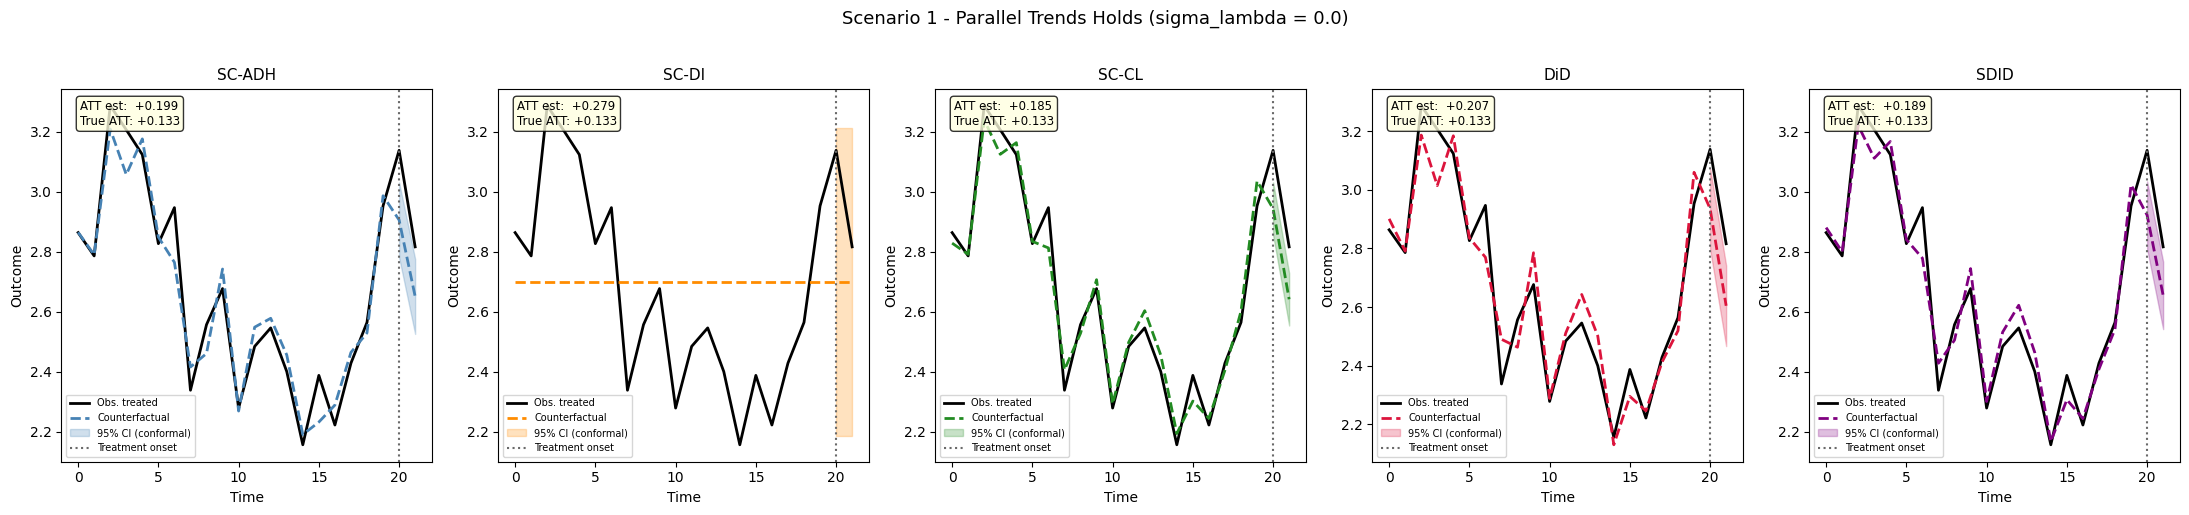

In [6]:
plot_scenario(
    models=[
        ('sc',   (r1_adh,  None),         df_pt),
        ('sc',   (r1_di,   None),         df_pt),
        ('sc',   (r1_cl,   None),         df_pt),
        ('did',  (r1_did,  r1_did_inf),   df_pt),
        ('sdid', (r1_sdid, r1_sdid_inf),  df_pt),
    ],
    true_att=true_att_pt,
    suptitle='Scenario 1 - Parallel Trends Holds (sigma_lambda = 0.0)',
)


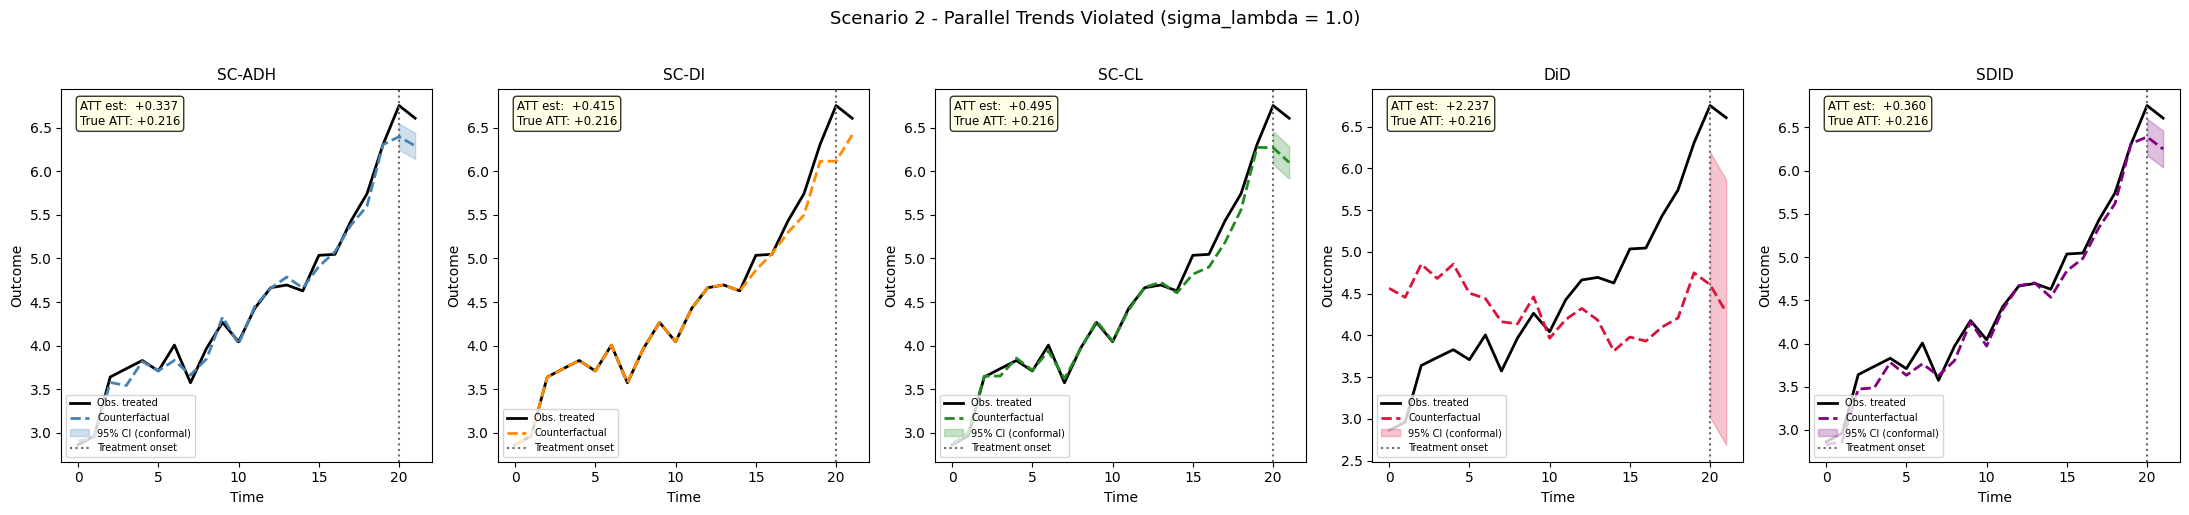

In [7]:
plot_scenario(
    models=[
        ('sc',   (r2_adh,  None),         df_viol),
        ('sc',   (r2_di,   None),         df_viol),
        ('sc',   (r2_cl,   None),         df_viol),
        ('did',  (r2_did,  r2_did_inf),   df_viol),
        ('sdid', (r2_sdid, r2_sdid_inf),  df_viol),
    ],
    true_att=true_att_viol,
    suptitle='Scenario 2 - Parallel Trends Violated (sigma_lambda = 1.0)',
)
